# ISP Functional Connectivity Network Statistics - Working Memory Load
## HCP parcellated task data

The HCP dataset comprises task-based fMRI from a large sample of human subjects. The NMA-curated dataset includes time series data that has been preprocessed and spatially-downsampled by aggregating within 360 regions of interest + 19 subcortical.

In order to use this dataset, please electronically sign the HCP data use terms at [ConnectomeDB](https://db.humanconnectome.org). Instructions for this are on pp. 24-25 of the [HCP Reference Manual](https://www.humanconnectome.org/storage/app/media/documentation/s1200/HCP_S1200_Release_Reference_Manual.pdf).

In this notebook, we will use parcellated WM task data for each participants, and perform functional connectivity - nbs analysis

In [ ]:
# @title Install dependencies
!pip install nilearn --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 76.6 MB/s eta 0:00:00


In [ ]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
#@title Figure settings
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.style.use("https://raw.githubusercontent.com/NeuromatchAcademy/course-content/main/nma.mplstyle")

> For a detailed description of the tasks have a look pages 45-54 of the [HCP reference manual](https://www.humanconnectome.org/storage/app/media/documentation/s1200/HCP_S1200_Release_Reference_Manual.pdf).

# Downloading data

The task data are shared in different files, but they will unpack into the same directory structure.


In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#  Load Subject Numpy Arrays - Parcellated Data

#   /MyDrive/data/sub-01/data.npy

BASE_DIR = "/content/drive/MyDrive/HCP_WM_Unrelated-100-subjects-Public/"
#BASE_DIR = "/content/drive/Shareddrives/Impact Scholars (Scholars External Drive)/DataSets/HCP_WM_Unrelated-100-subjects/"
DATA_DIR = BASE_DIR+"all_norm_pacel/"   # parent folder
SAVE_DIR = BASE_DIR  # parent folder

NPY_NAME = None

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configuration
N_SUBJECTS = 99
N_PARCELS = 379
TR = 0.72
RUNS = ['LR', 'RL']
WM_CONDITIONS = ['0bk_body', '0bk_faces', '0bk_places', '0bk_tools',
                 '2bk_body', '2bk_faces', '2bk_places', '2bk_tools']
                 # The parcels are matched across hemispheres with the same order
HEMIS = ["Right", "Left"]

# Each experiment was repeated twice in each subject
N_RUNS = 2

# There are 7 tasks. Each has a number of 'conditions'

EXPERIMENTS = {
    'MOTOR'      : {'runs': [5,6],   'cond':['lf','rf','lh','rh','t','cue']},
    'WM'         : {'runs': [7,8],   'cond':['0bk_body','0bk_faces','0bk_places','0bk_tools','2bk_body','2bk_faces','2bk_places','2bk_tools']},
    'EMOTION'    : {'runs': [9,10],  'cond':['fear','neut']},
    'GAMBLING'   : {'runs': [11,12], 'cond':['loss','win']},
    'LANGUAGE'   : {'runs': [13,14], 'cond':['math','story']},
    'RELATIONAL' : {'runs': [15,16], 'cond':['match','relation']},
    'SOCIAL'     : {'runs': [17,18], 'cond':['mental','rnd']}
}


In [ ]:
import os
import numpy as np

entries = sorted(os.listdir(DATA_DIR))

if NPY_NAME:   # subject folders
    sample_ids = sorted([
        e for e in entries
        if os.path.isdir(os.path.join(DATA_DIR, e))
    ])
else:          # flat .npy files
    sample_ids = sorted([
        e.replace('.npy', '') for e in entries if e.endswith('.npy')
    ])

sample_ids = np.array(sample_ids, dtype=str)

# Split into participant ID and run
participants = sorted(set(s.rsplit('_', 1)[0] for s in sample_ids))
participants = np.array(participants, dtype=str)
subjects = np.array(participants, dtype=str)

runs = ['LR', 'RL']

# Map participant -> available runs
participant_runs = {
    pid: [r for r in runs if f"{pid}_{r}" in sample_ids]
    for pid in participants
}

print("Sample IDs:")
print(sample_ids)

print("\nParticipants:")
print(participants)

print("\nParticipant -> runs:")
for pid, rr in participant_runs.items():
    print(pid, rr)

Sample IDs:
['100307_LR' '100307_RL' '100408_LR' '100408_RL' '101107_LR' '101107_RL'
 '101309_LR' '101309_RL' '101915_LR' '101915_RL' '103111_LR' '103111_RL'
 '103414_LR' '103414_RL' '103818_LR' '103818_RL' '105014_LR' '105014_RL'
 '105115_LR' '105115_RL' '106016_LR' '106016_RL' '108828_LR' '108828_RL'
 '110411_LR' '110411_RL' '111312_LR' '111312_RL' '111716_LR' '111716_RL'
 '113619_LR' '113619_RL' '113922_LR' '113922_RL' '114419_LR' '114419_RL'
 '115320_LR' '115320_RL' '116524_LR' '116524_RL' '117122_LR' '117122_RL'
 '118528_LR' '118528_RL' '118730_LR' '118730_RL' '118932_LR' '118932_RL'
 '120111_LR' '120111_RL' '122317_LR' '122317_RL' '122620_LR' '122620_RL'
 '123117_LR' '123117_RL' '123925_LR' '123925_RL' '124422_LR' '124422_RL'
 '125525_LR' '125525_RL' '126325_LR' '126325_RL' '127630_LR' '127630_RL'
 '127933_LR' '127933_RL' '128127_LR' '128127_RL' '128632_LR' '128632_RL'
 '129028_LR' '129028_RL' '130013_LR' '130013_RL' '130316_LR' '130316_RL'
 '131217_LR' '131217_RL' '131722_LR' '1

In [ ]:
import os
import numpy as np

# --------------------------------------------------
# 1. Discover files
# --------------------------------------------------
entries = sorted(os.listdir(DATA_DIR))

sample_ids = np.array(sorted([
    e.replace('.npy', '') for e in entries if e.endswith('.npy')
]), dtype=str)

participants = np.array(sorted(set(s.rsplit('_', 1)[0] for s in sample_ids)), dtype=str)
runs = ['LR', 'RL']

subject_paths = {
    sid: os.path.join(DATA_DIR, f"{sid}.npy")
    for sid in sample_ids
}

# --------------------------------------------------
# 2. Load arrays
# --------------------------------------------------
arrays = {}
problems = []

for sid, path in subject_paths.items():
    if not os.path.exists(path):
        print(f"[MISSING] {sid} -> {path}")
        problems.append(sid)
        continue

    arr = np.load(path, allow_pickle=False)

    if arr.ndim != 2:
        print(f"[BAD NDIM] {sid}: {arr.shape}")
        problems.append(sid)
        continue

    # convert raw (timepoint, parcel) -> (parcel, timepoint)
    if arr.shape[0] > arr.shape[1]:
        arr = arr.T

    arrays[sid] = arr
    print(f"[OK] {sid:15s} shape={arr.shape}")

# --------------------------------------------------
# 3. Shape check
# --------------------------------------------------
shapes = {s: a.shape for s, a in arrays.items()}
unique_shapes = set(shapes.values())

print("\nUnique shapes:", unique_shapes)

if len(unique_shapes) != 1:
    print("⚠ Inconsistent shapes:")
    for s, sh in shapes.items():
        print(f"  {s}: {sh}")

# --------------------------------------------------
# 4. Stack by participant and run
# --------------------------------------------------
valid_participants = [
    pid for pid in participants
    if all(f"{pid}_{r}" in arrays for r in runs)
]

data = np.stack([
    np.stack([arrays[f"{pid}_{r}"] for r in runs], axis=0)
    for pid in valid_participants
], axis=0)

print("\nFinal data shape:", data.shape)
print("Axis meaning: (participant, run, parcel, timepoint)")
print("Run order:", runs)

[OK] 100307_LR       shape=(379, 405)
[OK] 100307_RL       shape=(379, 405)
[OK] 100408_LR       shape=(379, 405)
[OK] 100408_RL       shape=(379, 405)
[OK] 101107_LR       shape=(379, 405)
[OK] 101107_RL       shape=(379, 405)
[OK] 101309_LR       shape=(379, 405)
[OK] 101309_RL       shape=(379, 405)
[OK] 101915_LR       shape=(379, 405)
[OK] 101915_RL       shape=(379, 405)
[OK] 103111_LR       shape=(379, 405)
[OK] 103111_RL       shape=(379, 405)
[OK] 103414_LR       shape=(379, 405)
[OK] 103414_RL       shape=(379, 405)
[OK] 103818_LR       shape=(379, 405)
[OK] 103818_RL       shape=(379, 405)
[OK] 105014_LR       shape=(379, 405)
[OK] 105014_RL       shape=(379, 405)
[OK] 105115_LR       shape=(379, 405)
[OK] 105115_RL       shape=(379, 405)
[OK] 106016_LR       shape=(379, 405)
[OK] 106016_RL       shape=(379, 405)
[OK] 108828_LR       shape=(379, 405)
[OK] 108828_RL       shape=(379, 405)
[OK] 110411_LR       shape=(379, 405)
[OK] 110411_RL       shape=(379, 405)
[OK] 111312_

#FILTERING

Original data shape : (100, 2, 379, 405)
Filtered data shape : (100, 2, 379, 405)
Shapes match        : True
Any NaNs in raw data?       False
Any NaNs in filtered data?  False

Participant: 100307
Parcel: 0
Runs: ['LR', 'RL']
Timepoints: 405
Last TR index: 404
Last time in seconds: 290.88


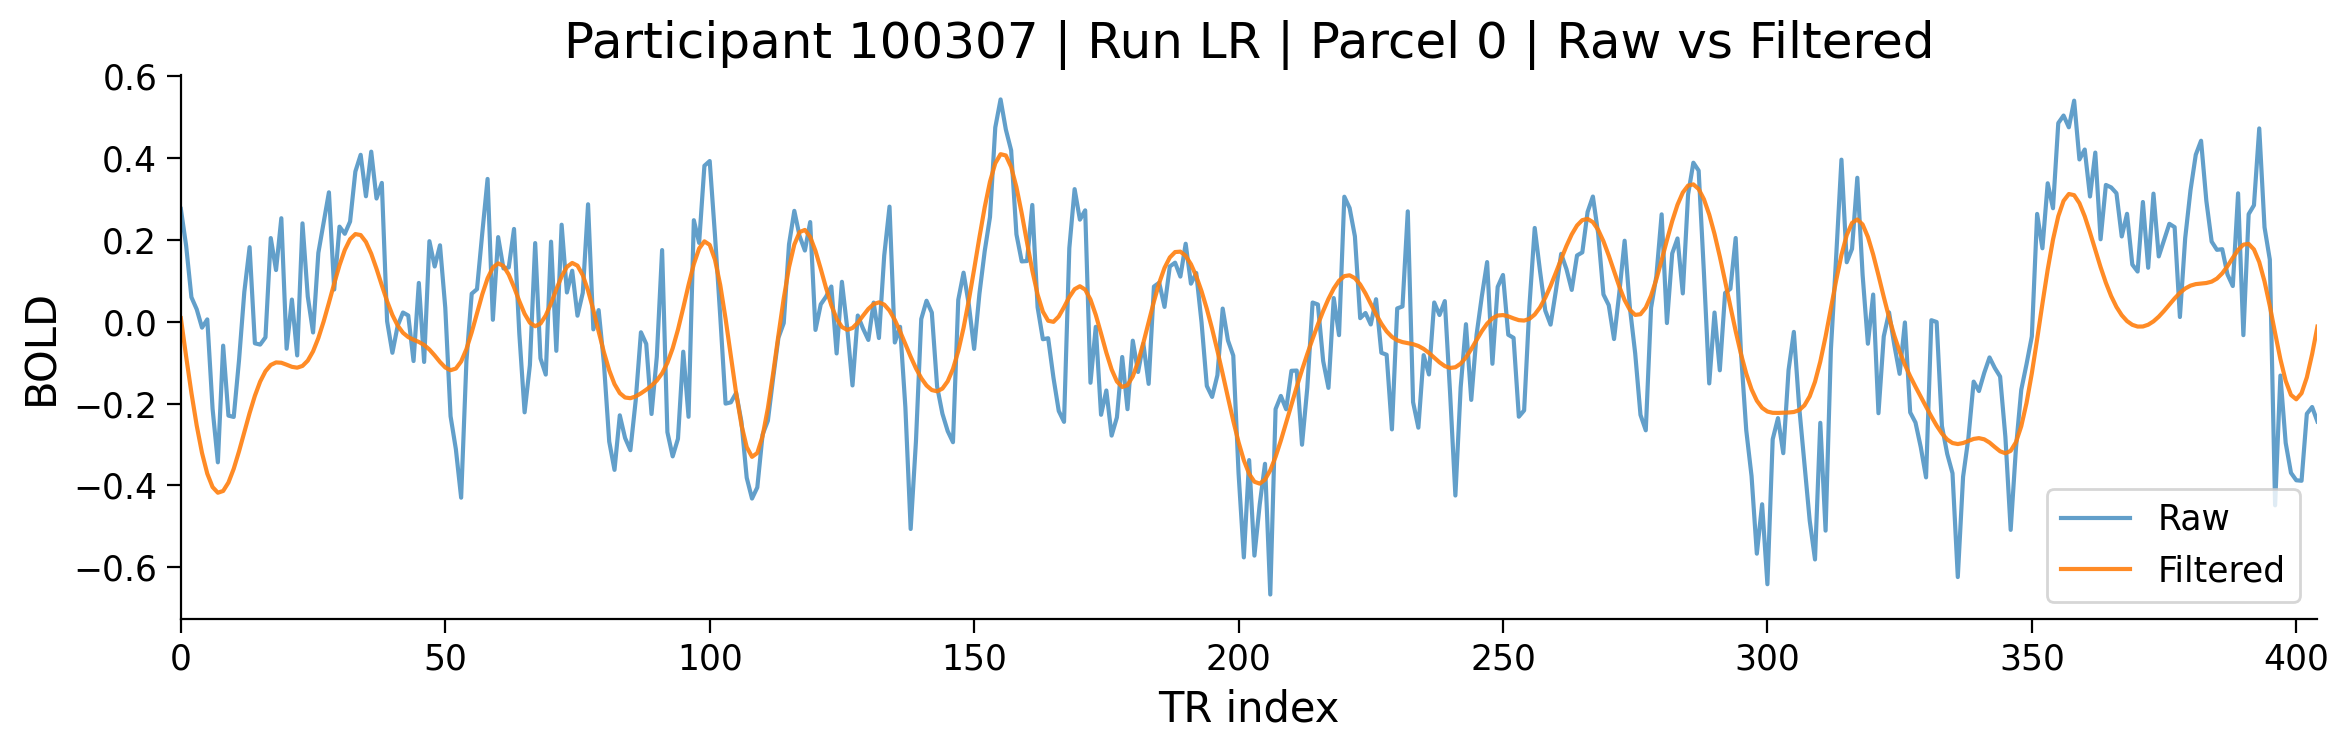

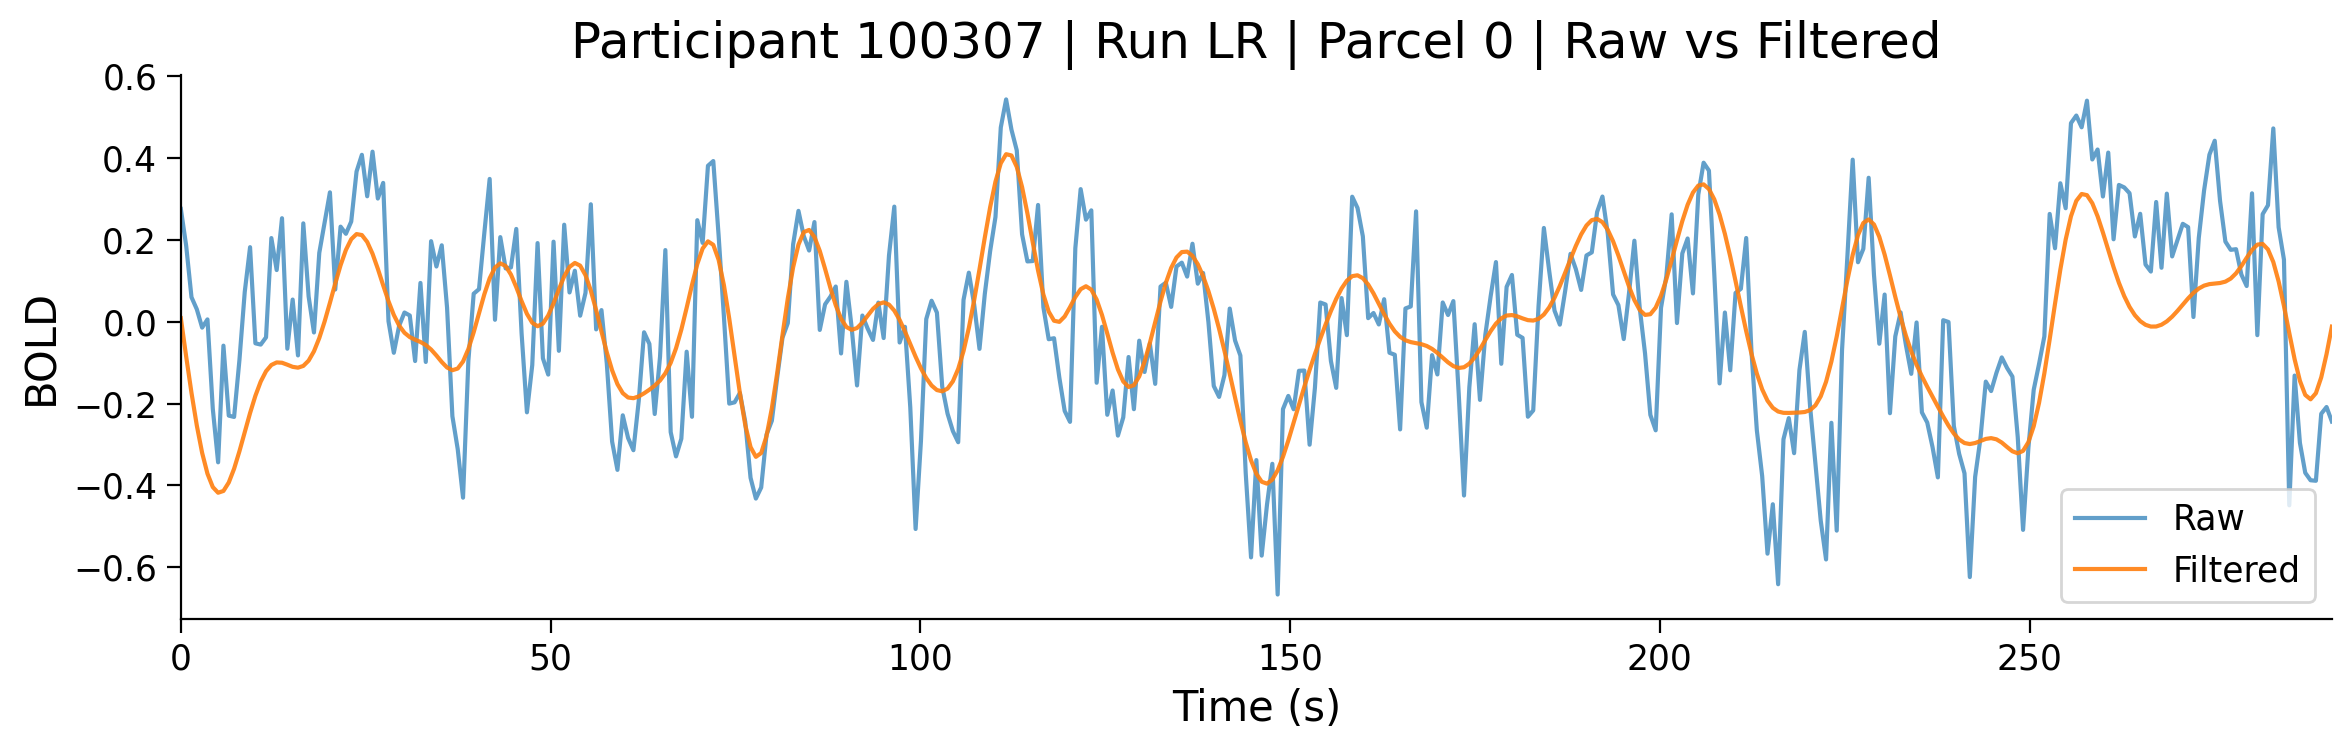

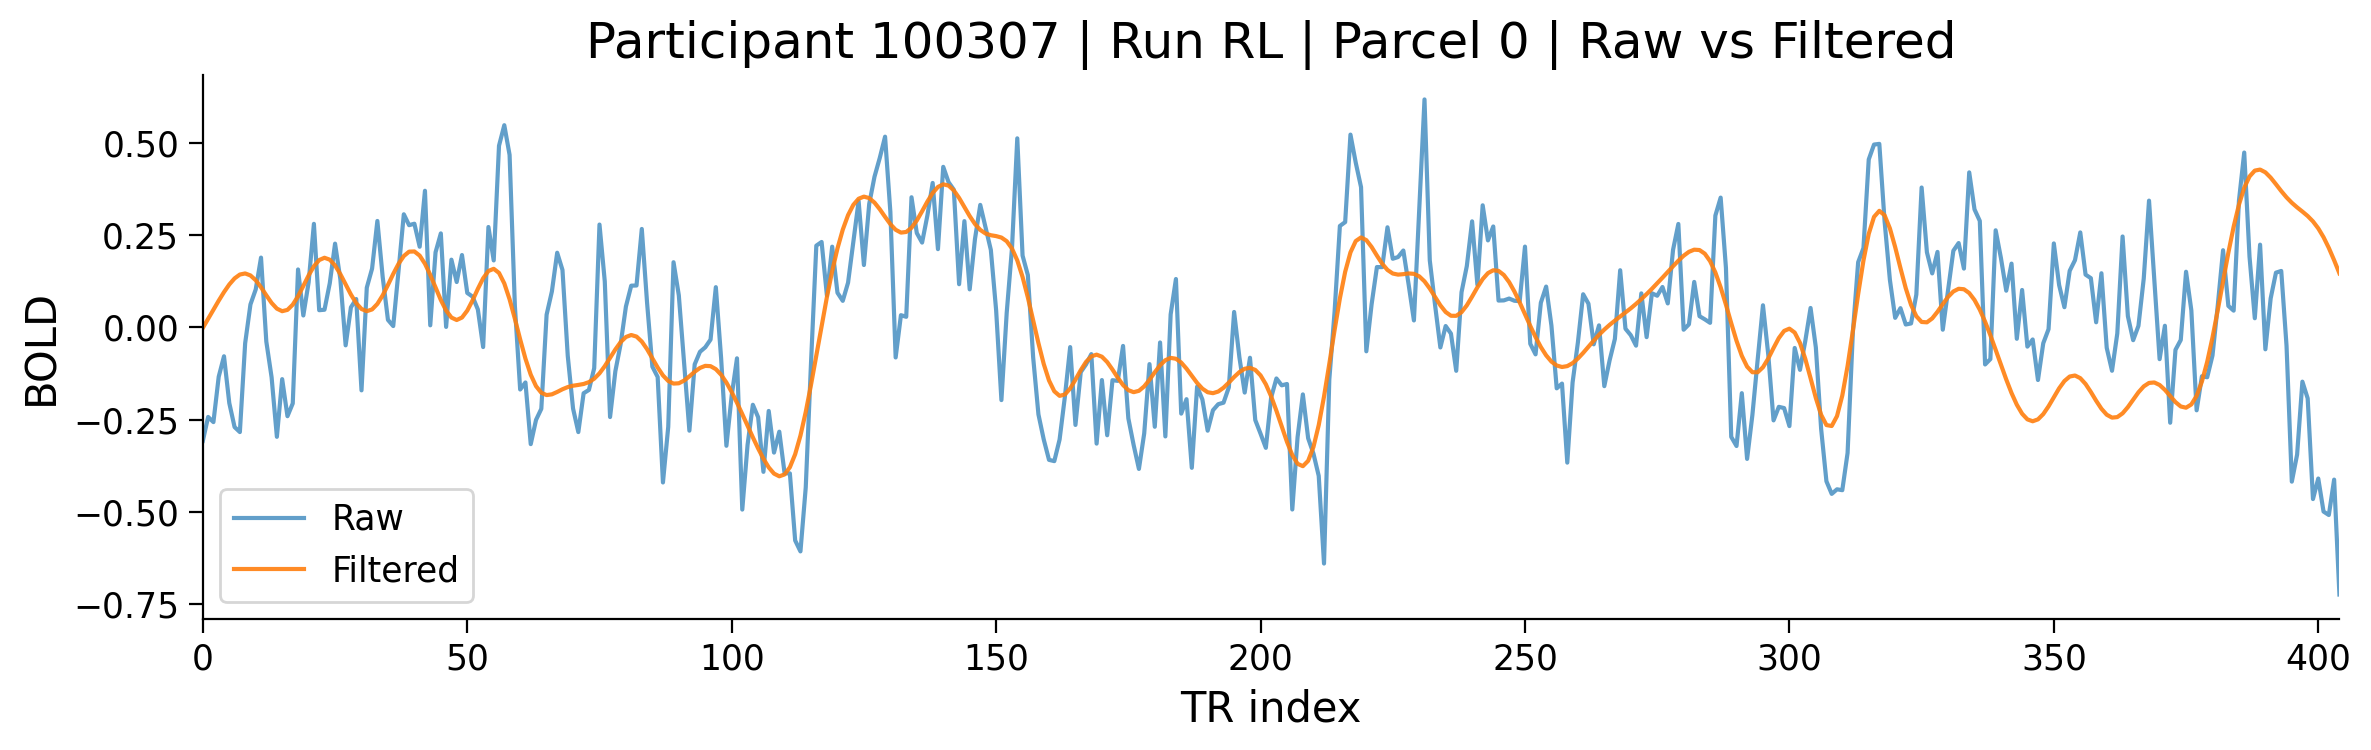

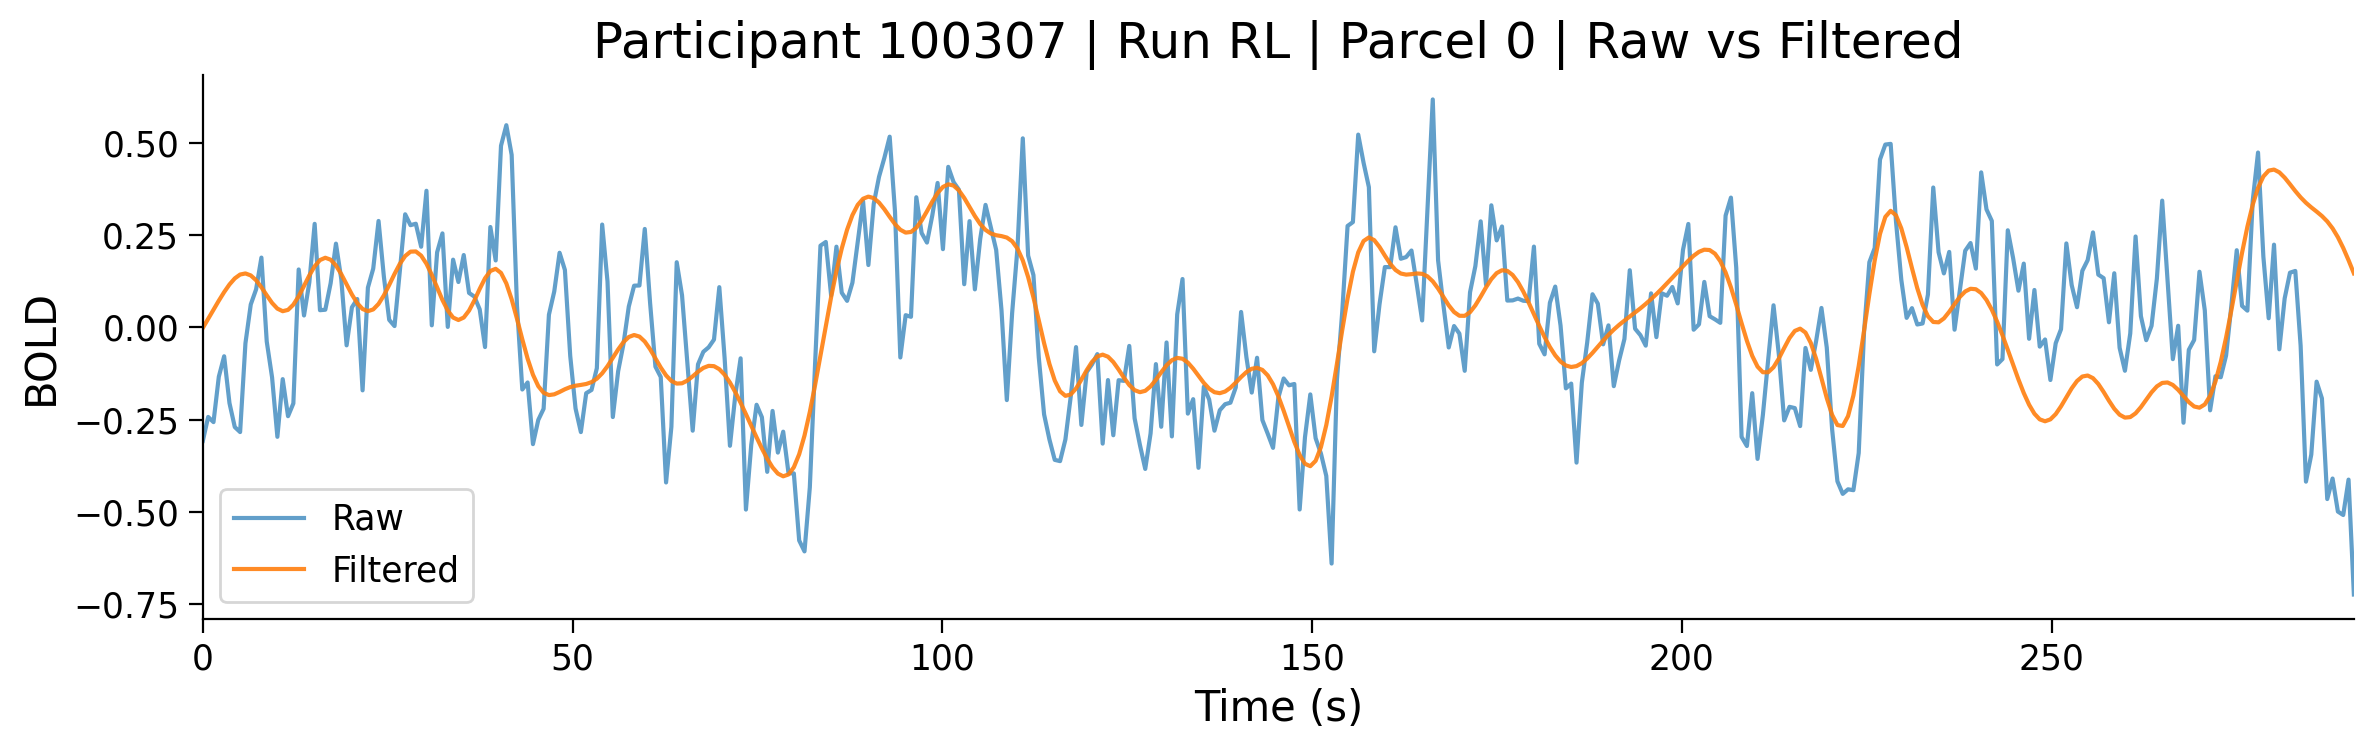

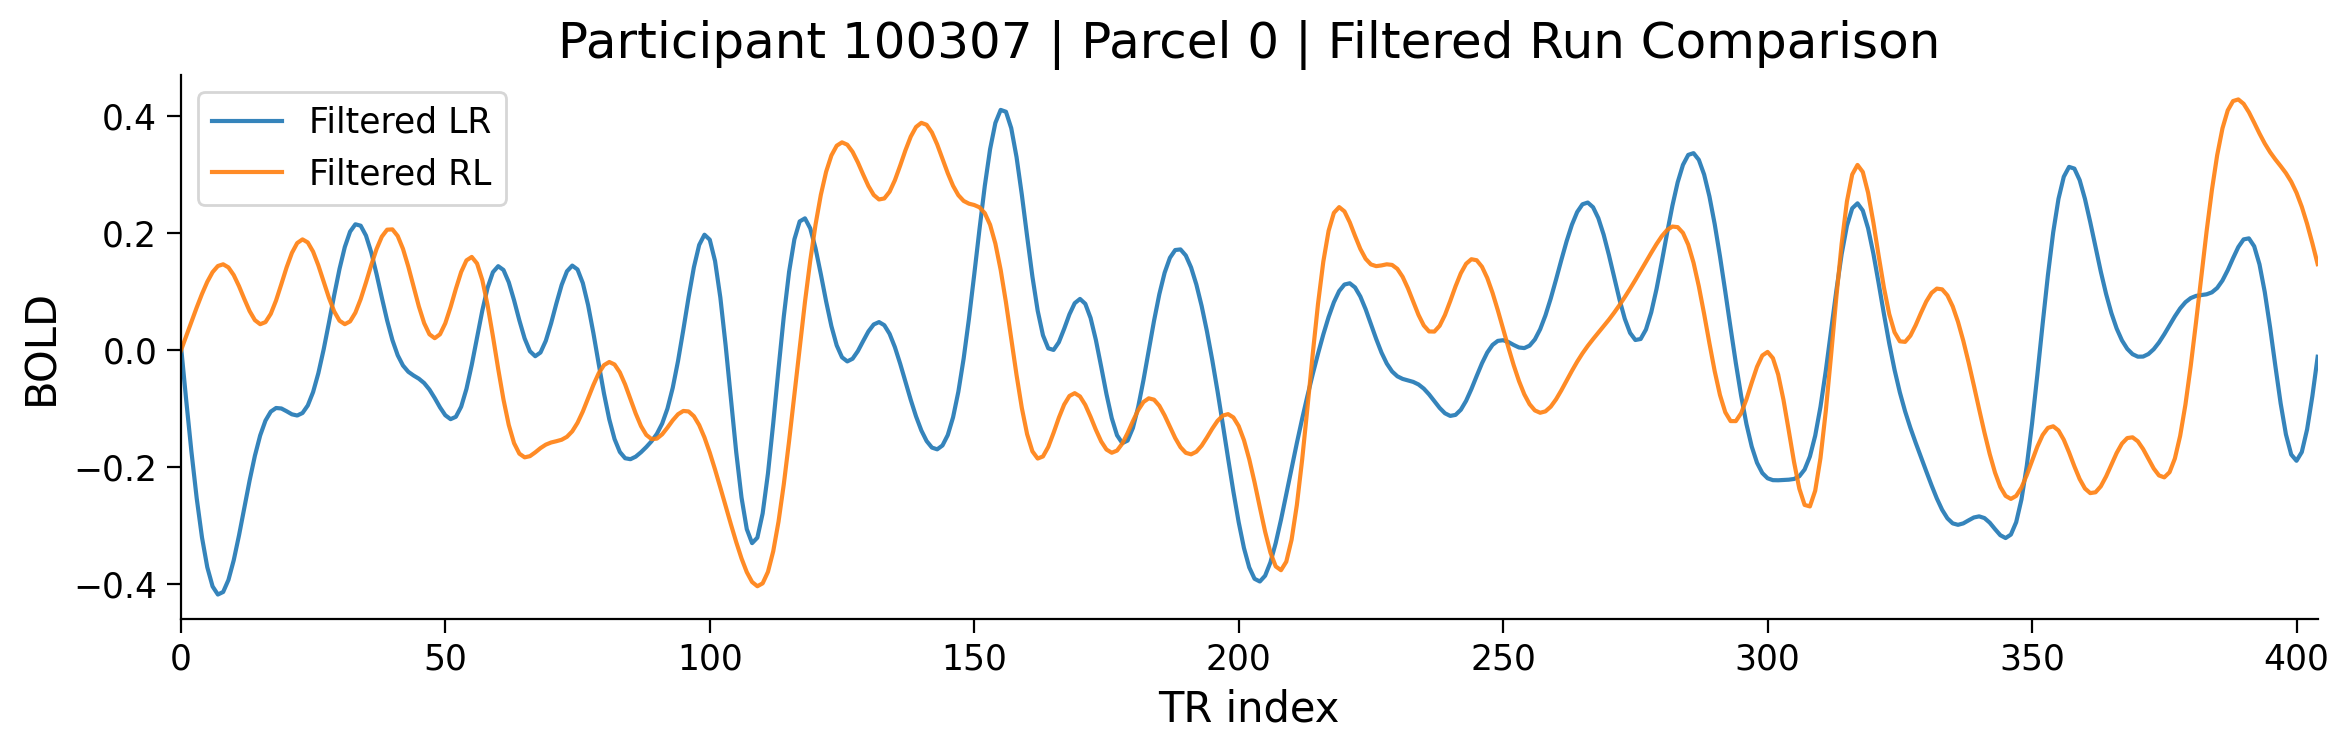

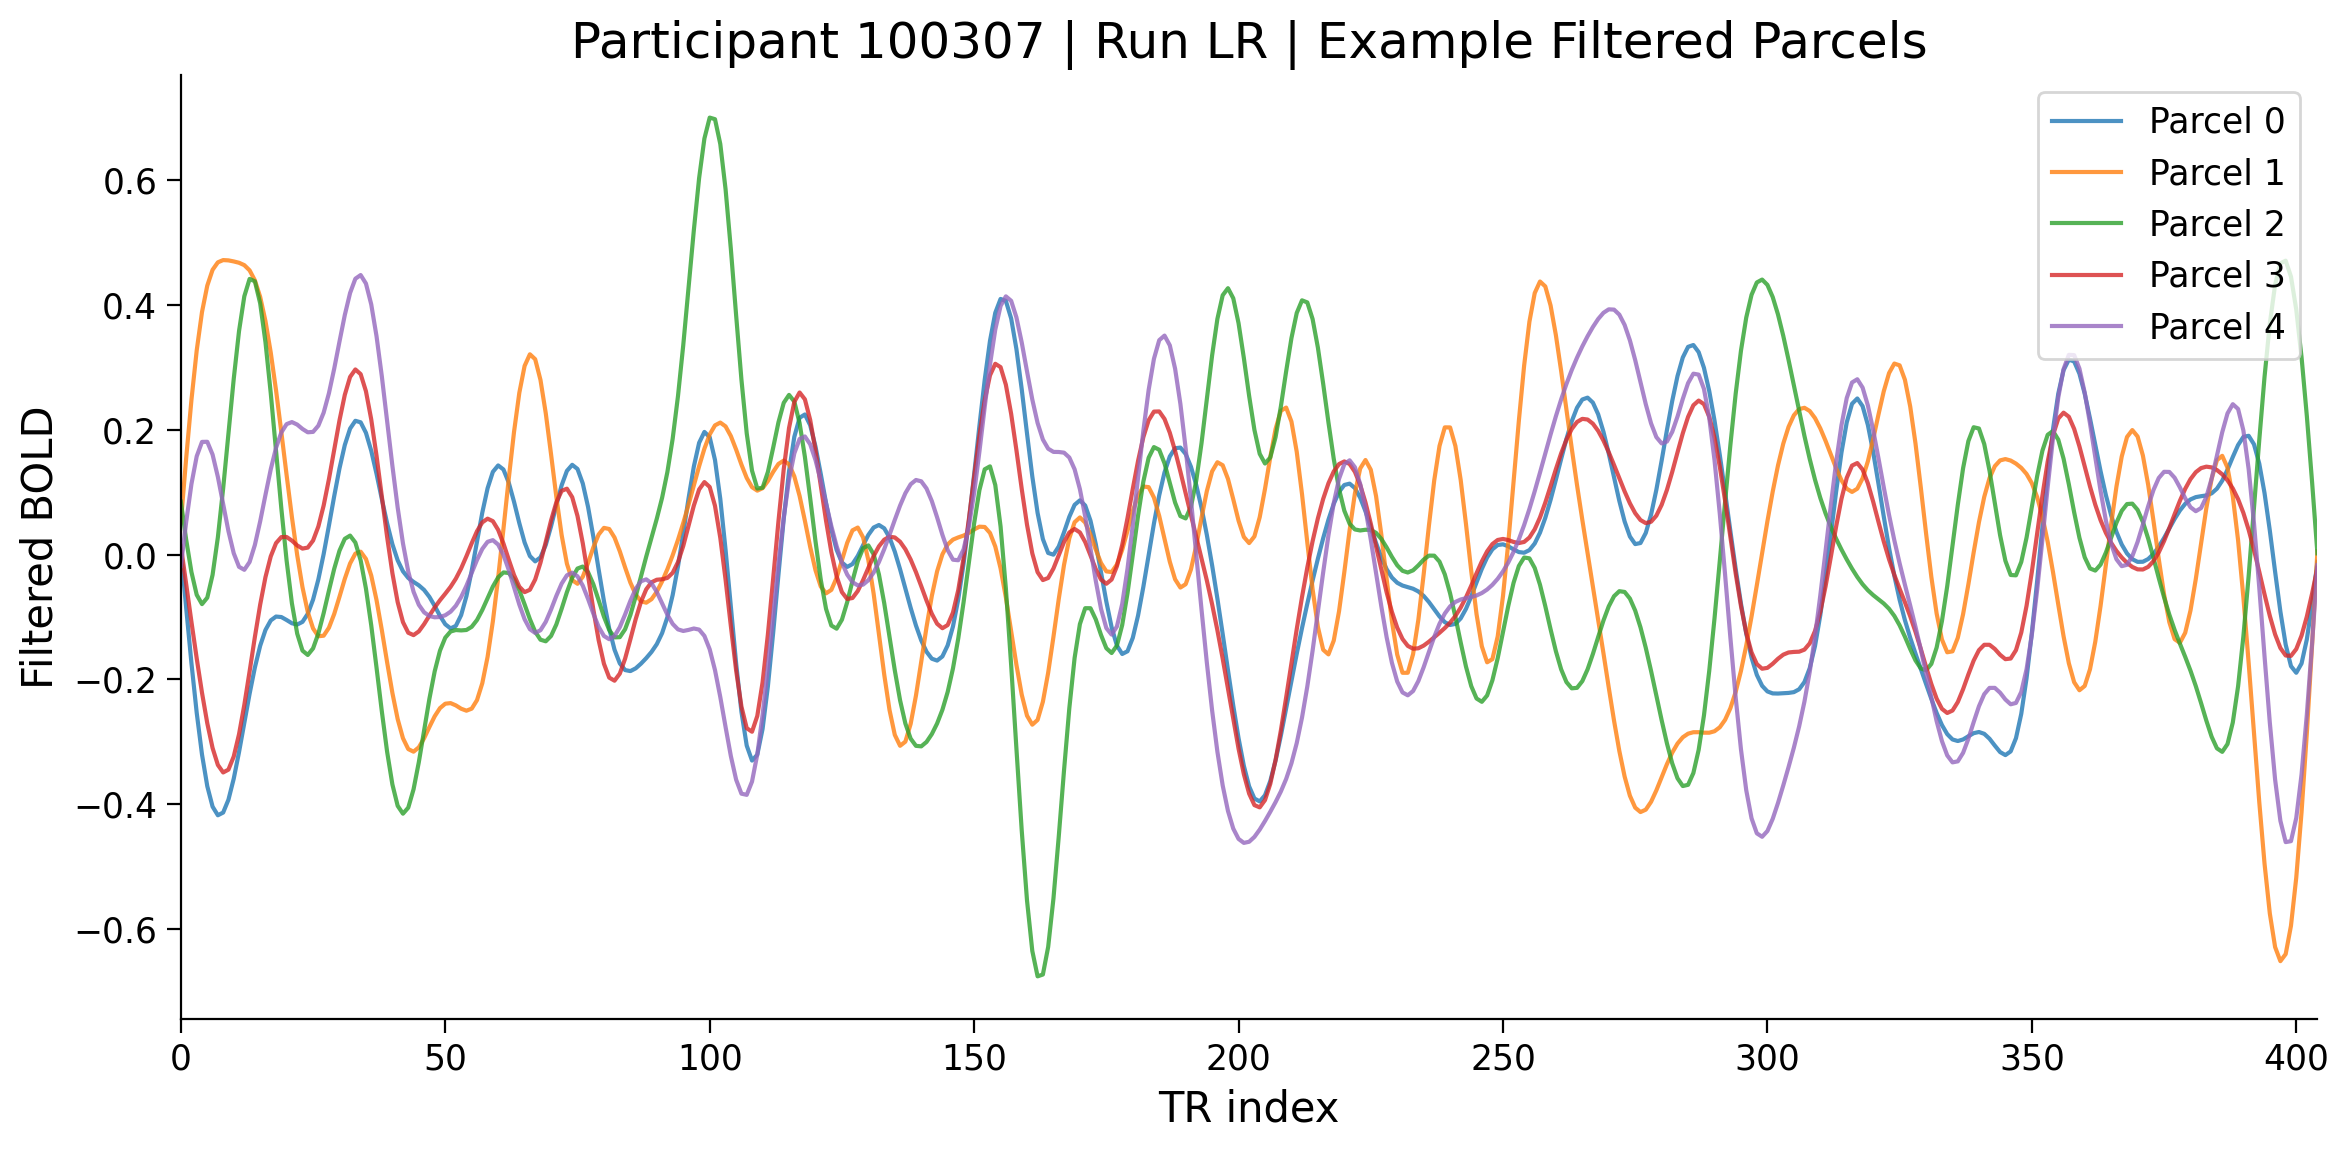

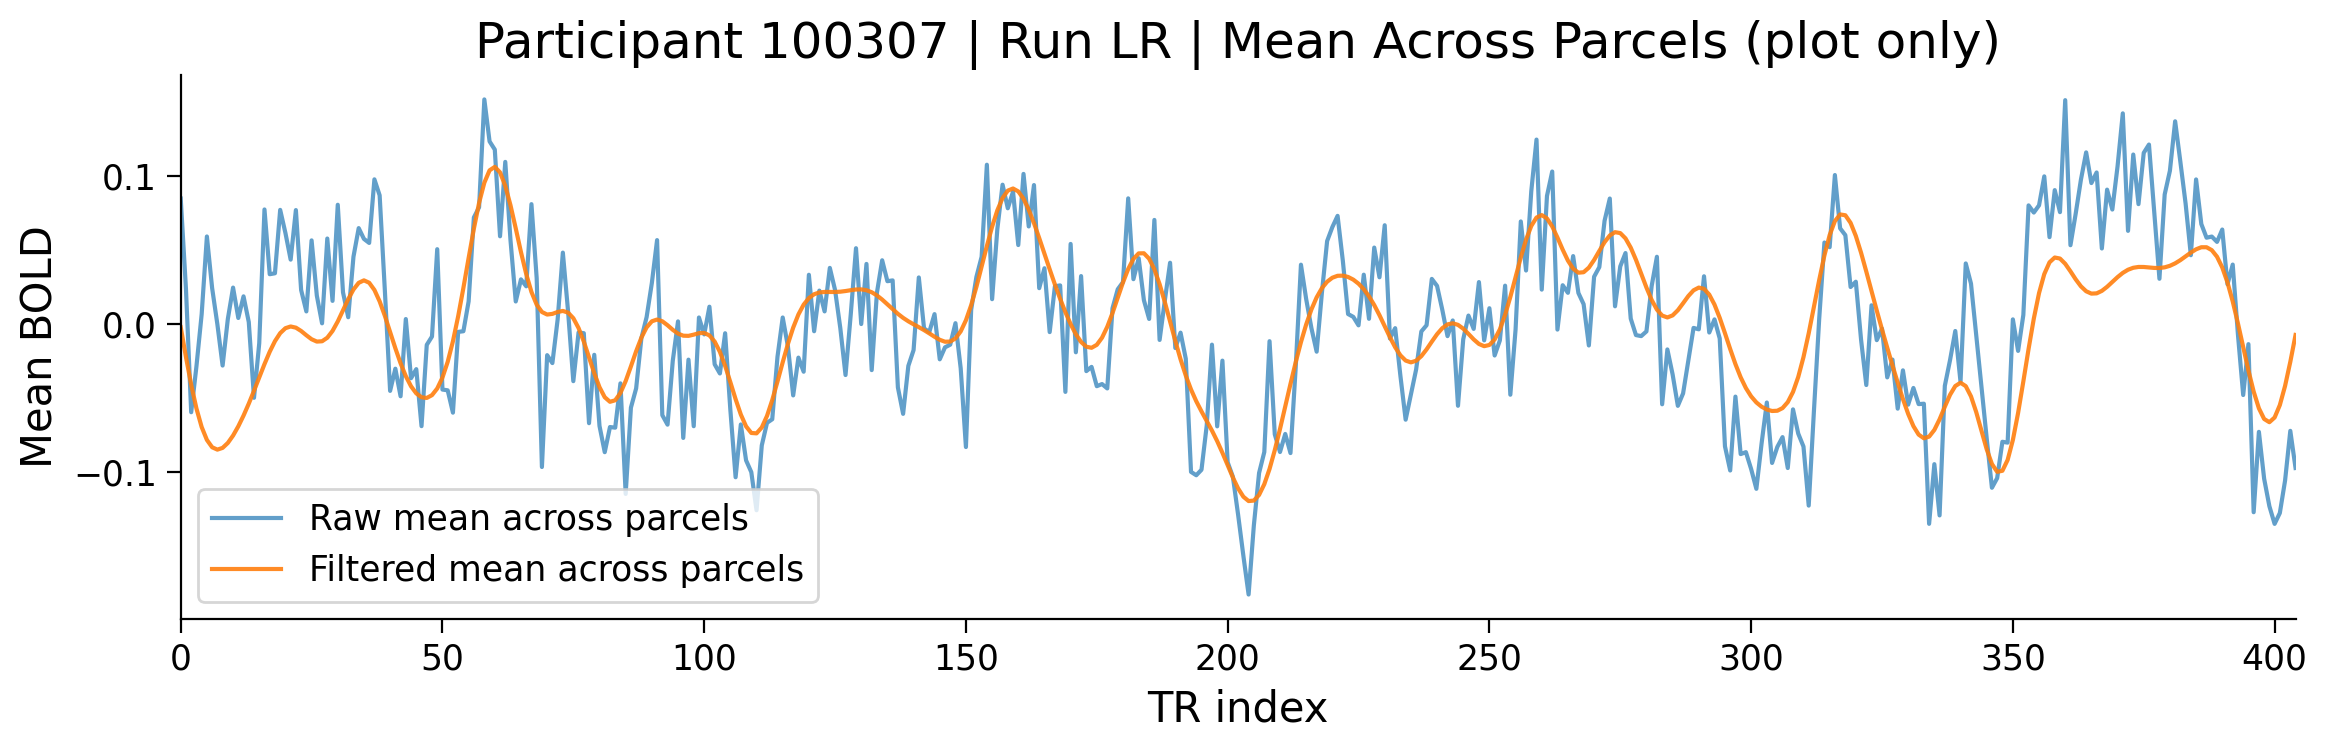

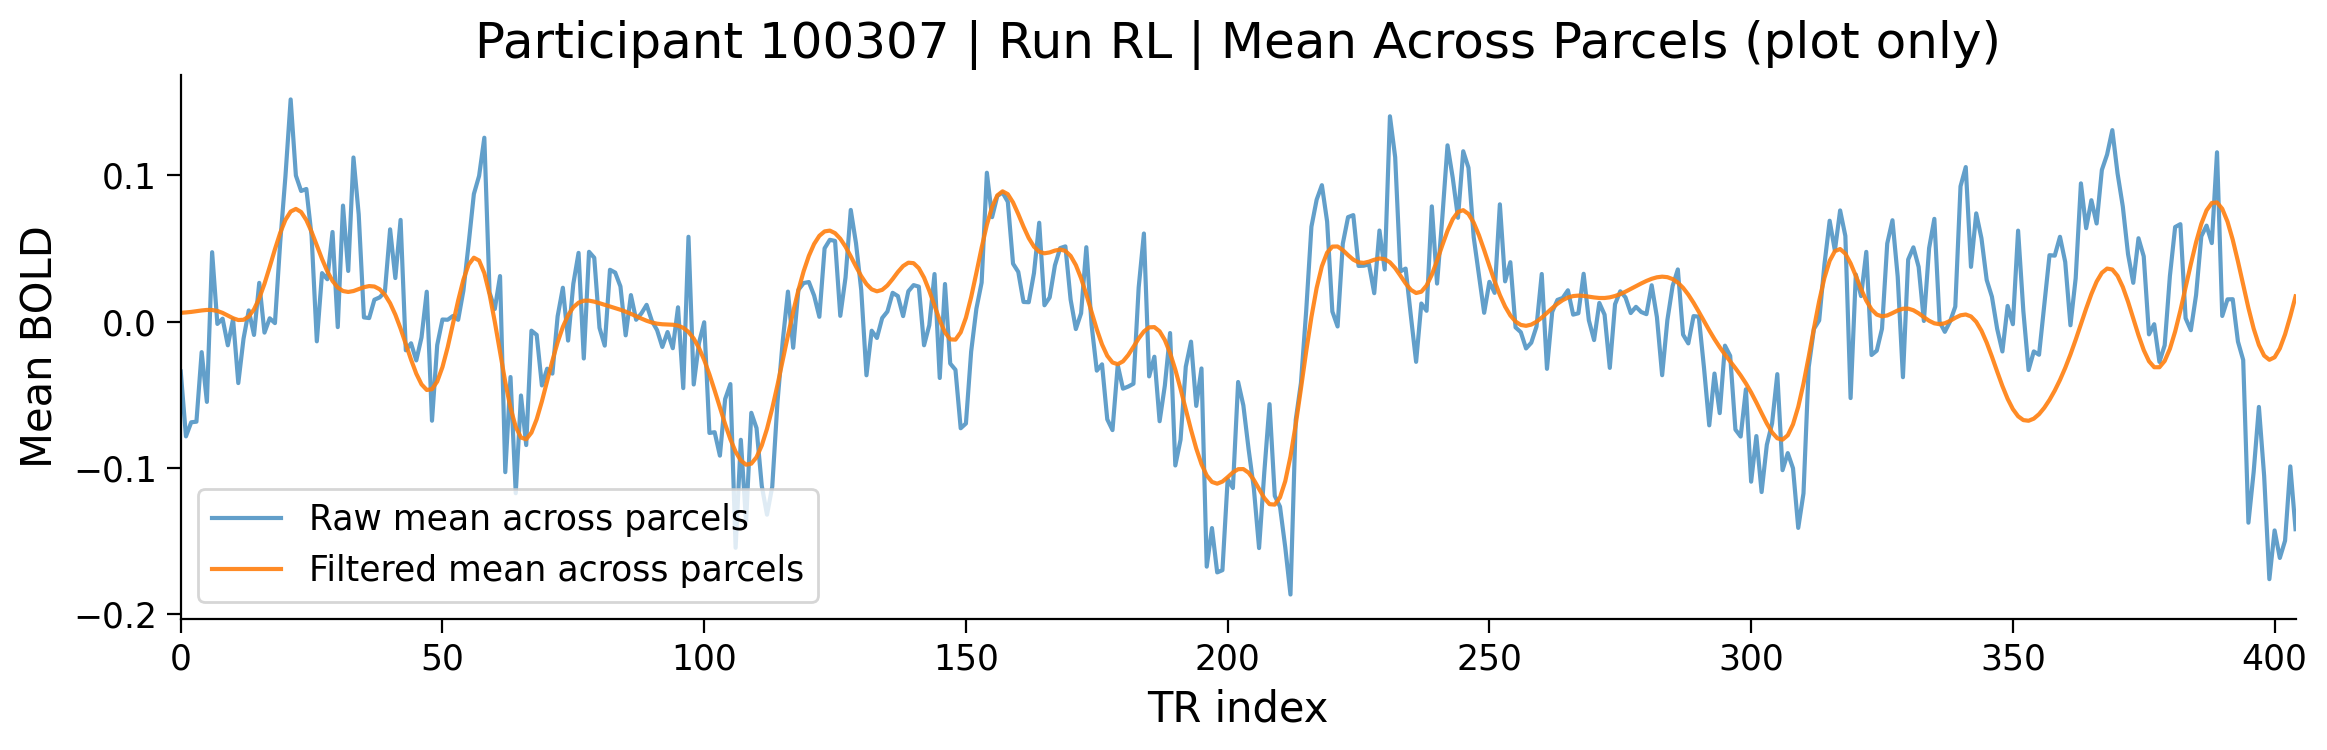

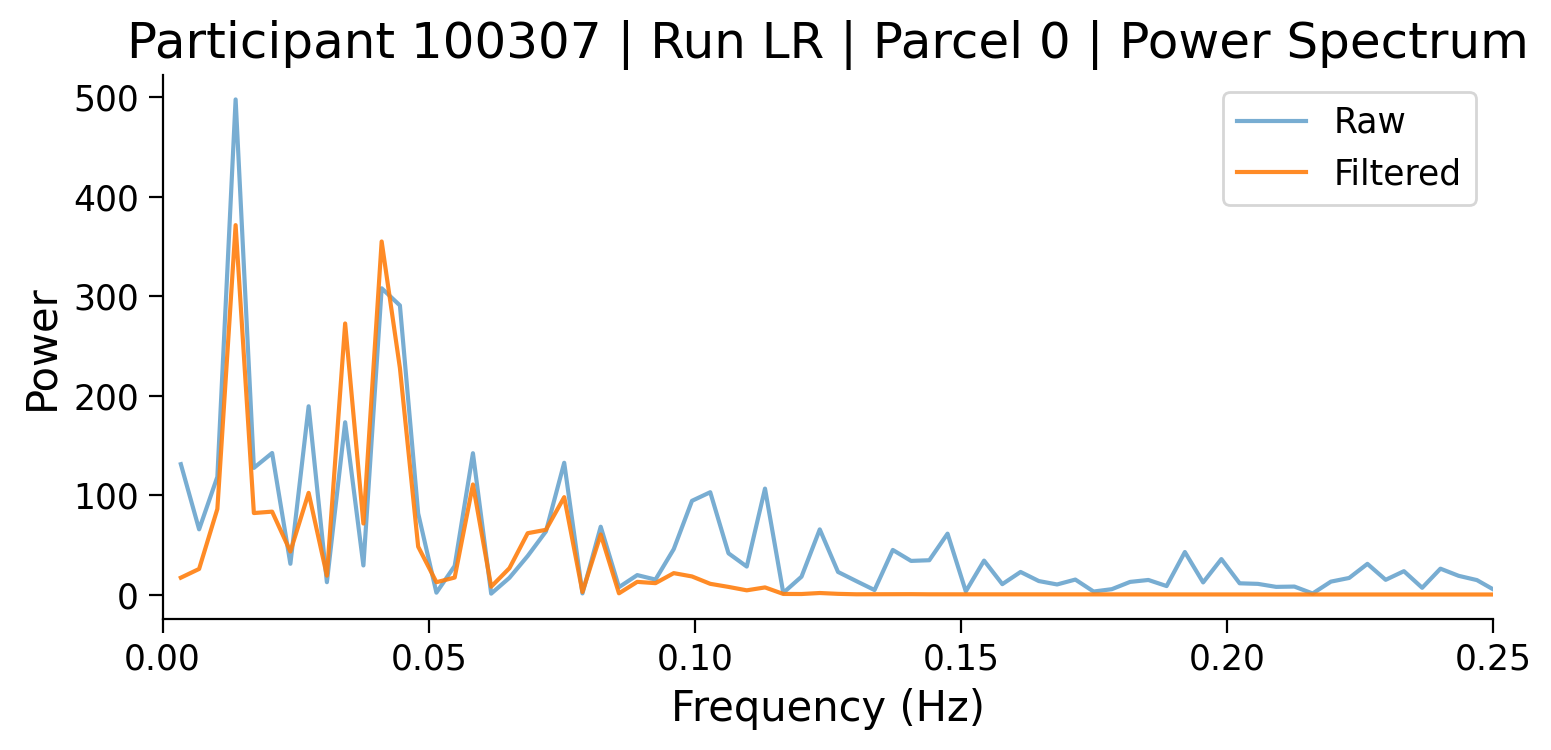

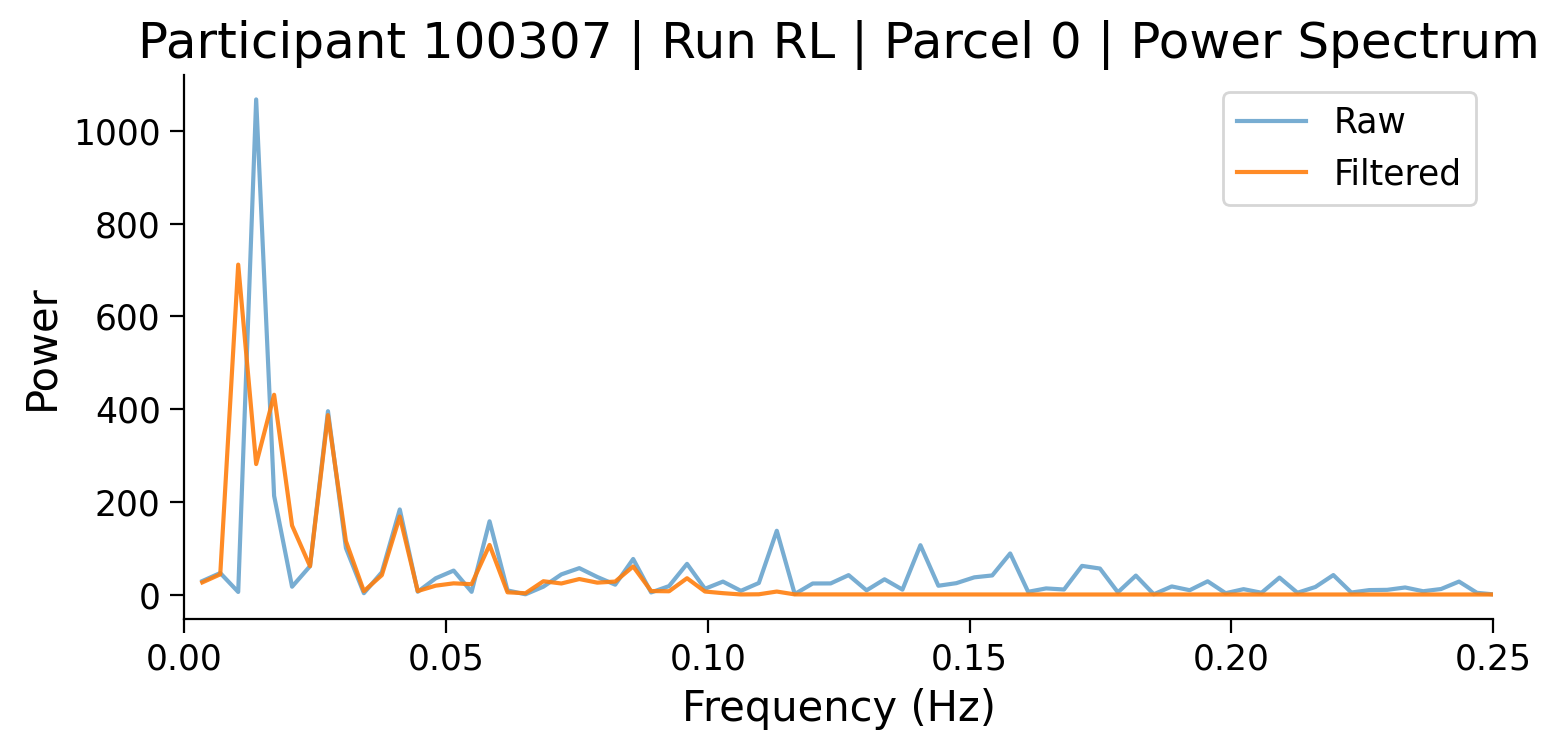


Done. data_filtered keeps the same shape as data.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import fft, fftfreq

# ==================================================
# Assumptions
# ==================================================
# data.shape == (n_participants, n_runs, n_parcels, n_timepoints)
# valid_participants is aligned with data
# runs = ['LR', 'RL']
# TR exists, e.g. TR = 0.72

# ==================================================
# 1. Bandpass filter
#    Filters each participant, each run, each parcel
#    separately across time, while preserving shape
# ==================================================
def bandpass_filter_timeseries(x, TR, cutoff_low=0.01, cutoff_high=0.1, order=5, axis=-1):
    fs = 1.0 / TR
    sos = signal.butter(
        order,
        [cutoff_low, cutoff_high],
        btype="bandpass",
        fs=fs,
        output="sos"
    )
    return signal.sosfiltfilt(sos, x, axis=axis)

data_filtered = bandpass_filter_timeseries(
    data,
    TR=TR,
    cutoff_low=0.01,
    cutoff_high=0.1,
    order=5,
    axis=3   # time axis
)

print("Original data shape :", data.shape)
print("Filtered data shape :", data_filtered.shape)
print("Shapes match        :", data.shape == data_filtered.shape)
print("Any NaNs in raw data?      ", np.isnan(data).any())
print("Any NaNs in filtered data? ", np.isnan(data_filtered).any())

# ==================================================
# 2. Choose one participant and one parcel to inspect
# ==================================================
participant_idx = 0
parcel_idx = 0

participant_id = valid_participants[participant_idx]
n_runs = data.shape[1]
n_timepoints = data.shape[3]

tr_axis = np.arange(n_timepoints)
time_sec = tr_axis * TR

print("\nParticipant:", participant_id)
print("Parcel:", parcel_idx)
print("Runs:", runs)
print("Timepoints:", n_timepoints)
print("Last TR index:", tr_axis[-1])
print("Last time in seconds:", time_sec[-1])

# ==================================================
# 3. Plot raw vs filtered for EACH RUN separately
# ==================================================
for run_idx in range(n_runs):
    run_label = runs[run_idx]

    raw_signal = data[participant_idx, run_idx, parcel_idx, :]
    filt_signal = data_filtered[participant_idx, run_idx, parcel_idx, :]

    plt.figure(figsize=(12, 4))
    plt.plot(tr_axis, raw_signal, label="Raw", alpha=0.7)
    plt.plot(tr_axis, filt_signal, label="Filtered", alpha=0.9)
    plt.xlabel("TR index")
    plt.ylabel("BOLD")
    plt.title(f"Participant {participant_id} | Run {run_label} | Parcel {parcel_idx} | Raw vs Filtered")
    plt.xlim(0, tr_axis[-1])
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 4))
    plt.plot(time_sec, raw_signal, label="Raw", alpha=0.7)
    plt.plot(time_sec, filt_signal, label="Filtered", alpha=0.9)
    plt.xlabel("Time (s)")
    plt.ylabel("BOLD")
    plt.title(f"Participant {participant_id} | Run {run_label} | Parcel {parcel_idx} | Raw vs Filtered")
    plt.xlim(0, time_sec[-1])
    plt.legend()
    plt.tight_layout()
    plt.show()

# ==================================================
# 4. Plot LR vs RL comparison for same participant/parcel
# ==================================================
if n_runs >= 2:
    plt.figure(figsize=(12, 4))
    for run_idx in range(n_runs):
        plt.plot(
            tr_axis,
            data_filtered[participant_idx, run_idx, parcel_idx, :],
            label=f"Filtered {runs[run_idx]}",
            alpha=0.9
        )
    plt.xlabel("TR index")
    plt.ylabel("BOLD")
    plt.title(f"Participant {participant_id} | Parcel {parcel_idx} | Filtered Run Comparison")
    plt.xlim(0, tr_axis[-1])
    plt.legend()
    plt.tight_layout()
    plt.show()

# ==================================================
# 5. Plot a few parcels for one participant and one run
#    This is only for visualization; no averaging is saved
# ==================================================
run_idx = 0   # choose a run to inspect
run_label = runs[run_idx]

example_parcels = [0, 1, 2, 3, 4]
example_parcels = [p for p in example_parcels if p < data.shape[2]]

plt.figure(figsize=(12, 6))
for p in example_parcels:
    plt.plot(tr_axis, data_filtered[participant_idx, run_idx, p, :], label=f"Parcel {p}", alpha=0.8)

plt.xlabel("TR index")
plt.ylabel("Filtered BOLD")
plt.title(f"Participant {participant_id} | Run {run_label} | Example Filtered Parcels")
plt.xlim(0, tr_axis[-1])
plt.legend()
plt.tight_layout()
plt.show()

# ==================================================
# 6. Mean across parcels for plotting only
#    This does NOT change or replace your filtered data
# ==================================================
for run_idx in range(n_runs):
    run_label = runs[run_idx]

    raw_mean = data[participant_idx, run_idx].mean(axis=0)
    filt_mean = data_filtered[participant_idx, run_idx].mean(axis=0)

    plt.figure(figsize=(12, 4))
    plt.plot(tr_axis, raw_mean, label="Raw mean across parcels", alpha=0.7)
    plt.plot(tr_axis, filt_mean, label="Filtered mean across parcels", alpha=0.9)
    plt.xlabel("TR index")
    plt.ylabel("Mean BOLD")
    plt.title(f"Participant {participant_id} | Run {run_label} | Mean Across Parcels (plot only)")
    plt.xlim(0, tr_axis[-1])
    plt.legend()
    plt.tight_layout()
    plt.show()

# ==================================================
# 7. Power spectrum for EACH RUN separately
# ==================================================
for run_idx in range(n_runs):
    run_label = runs[run_idx]

    raw_signal = data[participant_idx, run_idx, parcel_idx, :]
    filt_signal = data_filtered[participant_idx, run_idx, parcel_idx, :]

    raw_demean = raw_signal - np.mean(raw_signal)
    filt_demean = filt_signal - np.mean(filt_signal)

    n = len(raw_signal)
    freqs = fftfreq(n, TR)

    raw_power = np.abs(fft(raw_demean)) ** 2
    filt_power = np.abs(fft(filt_demean)) ** 2

    pos_mask = freqs > 0
    freqs_pos = freqs[pos_mask]
    raw_power_pos = raw_power[pos_mask]
    filt_power_pos = filt_power[pos_mask]

    plt.figure(figsize=(8, 4))
    plt.plot(freqs_pos, raw_power_pos, label="Raw", alpha=0.6)
    plt.plot(freqs_pos, filt_power_pos, label="Filtered", alpha=0.9)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Power")
    plt.title(f"Participant {participant_id} | Run {run_label} | Parcel {parcel_idx} | Power Spectrum")
    plt.xlim(0, 0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

print("\nDone. data_filtered keeps the same shape as data.")

## Loading region information

Downloading this dataset will create the `regions.npy` file, which contains the region name and network assignment for each parcel.

Detailed information about the name used for each region is provided [in the Supplement](https://static-content.springer.com/esm/art%3A10.1038%2Fnature18933/MediaObjects/41586_2016_BFnature18933_MOESM330_ESM.pdf) to [Glasser et al. 2016](https://www.nature.com/articles/nature18933).

Information about the network parcellation is provided in [Ji et al, 2019](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC6289683/).



In [ ]:
# ============================================================
# Install hcp_utils
# ============================================================
!pip install hcp_utils --quiet

# ============================================================
# Imports
# ============================================================
import numpy as np
import hcp_utils as hcp
from collections import Counter

# ============================================================
# Choose parcellation
# ============================================================
PARCELLATION = hcp.mmp   # 360 cortical parcels only

print(f"Parcellation has {PARCELLATION.nontrivial_ids.shape[0]} non-trivial parcels")
print(f"Parcel IDs range: {PARCELLATION.nontrivial_ids.min()} – {PARCELLATION.nontrivial_ids.max()}")

print("\nExample labels:")
for pid in list(PARCELLATION.labels.keys())[:5]:
    print(f"  id={pid}  name={PARCELLATION.labels[pid]}")

# ============================================================
# Helpers
# ============================================================
def infer_hemisphere(name):
    n = str(name).upper()

    # common MMP conventions
    if n.startswith("L_") or n.endswith("_L") or "_LH" in n or "LEFT" in n:
        return "L"
    if n.startswith("R_") or n.endswith("_R") or "_RH" in n or "RIGHT" in n:
        return "R"

    # explicit midline structure
    if "BRAINSTEM" in n or "BRAIN_STEM" in n:
        return "midline"

    # do not assume subcortical if the naming rule failed
    return "unknown"


def is_brainstem(name):
    n = str(name).upper()
    return ("BRAINSTEM" in n) or ("BRAIN_STEM" in n)

# ============================================================
# Build region_info dict with MMP -> CA network mapping
# ============================================================
mmp_map = np.asarray(hcp.mmp.map_all)
net_map = np.asarray(hcp.ca_network.map_all)

if mmp_map.shape != net_map.shape:
    raise ValueError(f"Shape mismatch: mmp.map_all={mmp_map.shape}, ca_network.map_all={net_map.shape}")

ids = np.asarray(PARCELLATION.nontrivial_ids)

index_list = []
parcel_id_list = []
name_list = []
network_list = []
hemi_list = []

for pid in ids:
    label = PARCELLATION.labels.get(int(pid), f"parcel_{pid}")

    # remove brainstem if present
    # (with hcp.mmp this usually won't remove anything,
    # because mmp is cortex-only)
    #if is_brainstem(label):
    #    continue

    hemi = infer_hemisphere(label)

    mask = (mmp_map == pid)
    overlapping_net_ids = net_map[mask]
    overlapping_net_ids = overlapping_net_ids[overlapping_net_ids > 0]

    if overlapping_net_ids.size == 0:
        network = "unknown"
    else:
        net_id = Counter(overlapping_net_ids.tolist()).most_common(1)[0][0]
        network = hcp.ca_network.labels.get(int(net_id), f"network_{net_id}")

    index_list.append(len(index_list))
    parcel_id_list.append(int(pid))
    name_list.append(label)
    network_list.append(network)
    hemi_list.append(hemi)

indices = np.asarray(index_list, dtype=np.int32)
parcel_ids = np.asarray(parcel_id_list, dtype=np.int32)
names = np.asarray(name_list, dtype=object)
networks = np.asarray(network_list, dtype=object)
hemis = np.asarray(hemi_list, dtype=object)

print(f"\nBuilt region_info for {len(parcel_ids)} parcels:")
print(f"{'idx':>4}  {'parcel_id':>10}  {'name':<30}  {'network':<25}  {'hemi'}")
print("-" * 95)
for i in range(min(15, len(parcel_ids))):
    print(f"{indices[i]:>4}  {parcel_ids[i]:>10}  {str(names[i]):<30}  {str(networks[i]):<25}  {hemis[i]}")
print(f"  ... ({len(parcel_ids)} total)")

region_info = {
    "index": indices,
    "parcel_id": parcel_ids,
    "name": names,
    "network": networks,
    "hemi": hemis,
}

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 34.2 MB/s eta 0:00:00


pixdim[1,2,3] should be non-zero; setting 0 dims to 1


Parcellation has 379 non-trivial parcels
Parcel IDs range: 1 – 379

Example labels:
  id=0  name=
  id=1  name=L_V1
  id=2  name=L_MST
  id=3  name=L_V6
  id=4  name=L_V2

Built region_info for 379 parcels:
 idx   parcel_id  name                            network                    hemi
-----------------------------------------------------------------------------------------------
   0           1  L_V1                            Visual1                    L
   1           2  L_MST                           Visual2                    L
   2           3  L_V6                            Visual2                    L
   3           4  L_V2                            Visual2                    L
   4           5  L_V3                            Visual2                    L
   5           6  L_V4                            Visual2                    L
   6           7  L_V8                            Visual2                    L
   7           8  L_4                             Somatomotor 

In [ ]:
brainstem_idx = [i for i, name in enumerate(name_list) if "brainstem" in str(name).lower()]
brainstem_idx

[378]

In [ ]:
np.unique(region_info['network' ])

array([np.str_('Auditory'), np.str_('Cingulo-Opercular'),
       np.str_('Default'), np.str_('Dorsal-attention'),
       np.str_('Frontoparietal'), np.str_('Language'),
       np.str_('Orbito-Affective'), np.str_('Posterior-Multimodal'),
       np.str_('Somatomotor'), np.str_('Ventral-Multimodal'),
       np.str_('Visual1'), np.str_('Visual2')], dtype=object)

In [ ]:
# Simulate your existing code pattern
for idx in range(min(5, n)):
    print({
        'index'   : idx,
        'name'    : region_info['name'][idx],
        'network' : region_info['network'][idx],
        'hemisphere': region_info['hemi'][idx],
    })

print(f"\n✓ region_info loaded successfully")
print(f"  Total regions : {len(region_info['name'])}")
print(f"  Unique networks : {sorted(set(region_info['network']))}")
print(f"  Unique hemispheres : {sorted(set(region_info['hemi']))}")


{'index': 0, 'name': np.str_('L_V1'), 'network': np.str_('Visual1'), 'hemisphere': 'L'}
{'index': 1, 'name': np.str_('L_MST'), 'network': np.str_('Visual2'), 'hemisphere': 'L'}
{'index': 2, 'name': np.str_('L_V6'), 'network': np.str_('Visual2'), 'hemisphere': 'L'}
{'index': 3, 'name': np.str_('L_V2'), 'network': np.str_('Visual2'), 'hemisphere': 'L'}
{'index': 4, 'name': np.str_('L_V3'), 'network': np.str_('Visual2'), 'hemisphere': 'L'}

✓ region_info loaded successfully
  Total regions : 379
  Unique networks : [np.str_('Auditory'), np.str_('Cingulo-Opercular'), np.str_('Default'), np.str_('Dorsal-attention'), np.str_('Frontoparietal'), np.str_('Language'), np.str_('Orbito-Affective'), np.str_('Posterior-Multimodal'), np.str_('Somatomotor'), np.str_('Ventral-Multimodal'), np.str_('Visual1'), np.str_('Visual2')]
  Unique hemispheres : ['L', 'R', 'midline']


# FUNCTIONAL CONNECTIVITY - Network Statistics

This part is to check how to run functional connectivity on subjects for different conditions how to get t-value matrices and so on

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
import os
import numpy as np

# Assumes these already exist:
# data         -> shape (n_subjects, n_parcels, 405)
# subjects     -> aligned with data
# EXPERIMENTS
# TR

BASE_DIR = "/content/drive/MyDrive/HCP_WM_Unrelated-100-subjects-Public/"
#BASE_DIR = "/content/drive/Shareddrives/Impact Scholars (Scholars External Drive)/DataSets/HCP_WM_Unrelated-100-subjects/"
WM_CONDITIONS = EXPERIMENTS["WM"]["cond"]
SAVE_DATA_DIR = BASE_DIR+"data"
SAVE_FC_DIR = BASE_DIR+"FCs"



In [ ]:
import os
import json
import numpy as np

def to_jsonable(obj):
    """
    Recursively convert numpy objects to JSON-serializable Python objects.
    """
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, (np.integer,)):
        return int(obj)
    elif isinstance(obj, (np.floating,)):
        return float(obj)
    elif isinstance(obj, (np.bool_,)):
        return bool(obj)
    elif isinstance(obj, dict):
        return {str(k): to_jsonable(v) for k, v in obj.items()}
    elif isinstance(obj, (list, tuple)):
        return [to_jsonable(v) for v in obj]
    else:
        return obj


def save_core_inputs(data, subjects, region_info, save_dir):
    """
    Save:
      - data array
      - subjects list
      - region_info
      - subjects as txt
    """
    out_dir = os.path.join(save_dir, "core_inputs")
    os.makedirs(out_dir, exist_ok=True)

    print("\nSaving core inputs to:", out_dir)

    # --------------------------------------------------
    # 1. Save full data
    # --------------------------------------------------
    np.save(os.path.join(out_dir, "data.npy"), data)
    np.savez_compressed(os.path.join(out_dir, "data_compressed.npz"), data=data)
    print("Saved: data.npy and data_compressed.npz")

    # --------------------------------------------------
    # 2. Save subjects
    # --------------------------------------------------
    subjects = np.asarray(subjects).astype(str)

    np.save(os.path.join(out_dir, "subjects.npy"), subjects)

    with open(os.path.join(out_dir, "subjects.txt"), "w") as f:
        for s in subjects:
            f.write(f"{s}\n")

    print("Saved: subjects.npy and subjects.txt")

    # --------------------------------------------------
    # 3. Save region_info
    # --------------------------------------------------
    # Save raw numpy/object version no matter what
    np.save(
        os.path.join(out_dir, "region_info.npy"),
        np.array(region_info, dtype=object),
        allow_pickle=True
    )
    print("Saved: region_info.npy")

    # Also try to save JSON-friendly version
    try:
        region_info_jsonable = to_jsonable(region_info)
        with open(os.path.join(out_dir, "region_info.json"), "w") as f:
            json.dump(region_info_jsonable, f, indent=2)
        print("Saved: region_info.json")
    except Exception as e:
        print(f"[WARNING] Could not save region_info.json: {e}")

    # --------------------------------------------------
    # 4. Save metadata
    # --------------------------------------------------
    meta = {
        "data_shape": list(data.shape),
        "n_subjects": int(len(subjects)),
        "n_runs": int(data.shape[1]),
        "n_parcels": int(data.shape[2]),
        "n_timepoints": int(data.shape[3]),
    }

    with open(os.path.join(out_dir, "dataset_metadata.json"), "w") as f:
        json.dump(meta, f, indent=2)

    print("Saved: dataset_metadata.json")
    print("\nDone saving core inputs.\n")


# RUN
save_core_inputs(
    data=data,
    subjects=subjects,
    region_info=region_info,
    save_dir=SAVE_DATA_DIR,
)


Saving core inputs to: /content/drive/Shareddrives/Impact Scholars (Scholars External Drive)/DataSets/HCP_WM_Unrelated-100-subjects/data/core_inputs
Saved: data.npy and data_compressed.npz
Saved: subjects.npy and subjects.txt
Saved: region_info.npy
Saved: region_info.json
Saved: dataset_metadata.json

Done saving core inputs.



In [ ]:
def load_evs(subject, experiment, run_name, base_dir, n_trs, lag_s):
    """
    Returns:
        frames_list: list over conditions
                     each item is a list of frame arrays, one per block
    """
    frames_list = []

    for cond in EXPERIMENTS[experiment]["cond"]:
        ev_file = os.path.join(
            base_dir, str(subject), experiment, run_name, "EVs", f"{cond}.txt"
        )

        if not os.path.exists(ev_file):
            print(f"[WARNING] Missing EV file: {ev_file}")
            frames_list.append([])
            continue

        ev_array = np.loadtxt(ev_file, ndmin=2, unpack=True)
        ev_array = np.asarray(ev_array)

        if ev_array.ndim == 1:
              ev_array = ev_array[:, None]
        if ev_array.ndim == 1:
            ev_array = ev_array[:, None]

        if ev_array.shape[0] != 3:
            raise ValueError(f"Unexpected EV shape in {ev_file}: {ev_array.shape}")

        ev = dict(zip(["onset", "duration", "amplitude"], ev_array))

        start    = np.floor((ev["onset"] + lag_s)/ TR).astype(int)
        duration = np.ceil(ev["duration"] / TR).astype(int)

        frames = []
        for i, (s, d) in enumerate(zip(start, duration)):
              # Shift window start backward to use pre-onset TRs
              win_start = s

              # For the last block, extend window to capture HRF tail
              win_end = s + d

              f = np.arange(win_start, win_end)

              # Clip to valid TR range
              if win_start < 0:
                  print(f"[WARNING] {cond} block {i}: window starts before run "
                        f"(TR {win_start}), clipping {abs(win_start)} TRs from start")
              if win_end > n_trs:
                  print(f"[WARNING] {cond} block {i}: window extends beyond run "
                        f"(TR {win_end} > {n_trs}), clipping {win_end - n_trs} TRs from end")

              f = f[(f >= 0) & (f < n_trs)]
              frames.append(f)
        frames_list.append(frames)
    return frames_list

In [ ]:

lag_s  = 8 * TR # 5.76
RUNS   = ['LR', 'RL']
n_trs  = data.shape[3]   # or whatever your TR count is

result = load_evs(subjects[0], 'WM', RUNS[0], BASE_DIR, n_trs, lag_s)

In [ ]:
result

[[array([58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74,
         75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91,
         92, 93, 94, 95, 96])],
 [array([316, 317, 318, 319, 320, 321, 322, 323, 324, 325, 326, 327, 328,
         329, 330, 331, 332, 333, 334, 335, 336, 337, 338, 339, 340, 341,
         342, 343, 344, 345, 346, 347, 348, 349, 350, 351, 352, 353, 354])],
 [array([355, 356, 357, 358, 359, 360, 361, 362, 363, 364, 365, 366, 367,
         368, 369, 370, 371, 372, 373, 374, 375, 376, 377, 378, 379, 380,
         381, 382, 383, 384, 385, 386, 387, 388, 389, 390, 391, 392, 393])],
 [array([157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169,
         170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182,
         183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195])],
 [array([217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229,
         230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 2

In [ ]:
np.shape(result)

(8, 1, 39)

In [ ]:
import os
import json
import numpy as np

# ============================================================
# REQUIRED INPUTS
# ============================================================
# data.shape = (n_subjects, 2, n_parcels, n_timepoints)
# subjects aligned with data
# BASE_DIR
# SAVE_DATA_DIR
# TR
# EXPERIMENTS["WM"]["cond"]

RUN_NAMES = ["LR", "RL"]


# ============================================================
# HELPERS
# ============================================================
def get_subject_index(subject, subjects):
    subjects = np.asarray(subjects).astype(str)
    idx = np.where(subjects == str(subject))[0]
    if len(idx) == 0:
        raise ValueError(f"Subject {subject} not found in subjects.")
    return idx[0]


def get_run_index(run_name):
    if run_name not in RUN_NAMES:
        raise ValueError(f"run_name must be one of {RUN_NAMES}, got {run_name}")
    return RUN_NAMES.index(run_name)


def concatenate_blocks(block_ts_list, n_parcels):
    if len(block_ts_list) == 0:
        return np.empty((n_parcels, 0))
    return np.concatenate(block_ts_list, axis=1)


# ============================================================
# EV LOADING
# ============================================================
def load_evs(subject, experiment, run_name, base_dir, n_trs, lag_s):
    """
    lag_s: lag in seconds (default = 8 * TR = 5.76s, close to 6s HRF peak = 8 TRs)
    Returns:
        frames_list: list over conditions
                     each item is a list of frame arrays, one per block
    """
    frames_list = []

    for cond in EXPERIMENTS[experiment]["cond"]:
        ev_file = os.path.join(
            base_dir, str(subject), experiment, run_name, "EVs", f"{cond}.txt"
        )

        if not os.path.exists(ev_file):
            print(f"[WARNING] Missing EV file: {ev_file}")
            frames_list.append([])
            continue

        ev_array = np.loadtxt(ev_file, ndmin=2, unpack=True)
        ev_array = np.asarray(ev_array)

        if ev_array.ndim == 1:
            ev_array = ev_array[:, None]

        if ev_array.shape[0] != 3:
            raise ValueError(f"Unexpected EV shape in {ev_file}: {ev_array.shape}")

        ev = dict(zip(["onset", "duration", "amplitude"], ev_array))

        start    = np.floor((ev["onset"] + lag_s) / TR).astype(int)
        duration = np.ceil(ev["duration"] / TR).astype(int)

        frames = []
        for i, (s, d) in enumerate(zip(start, duration)):
            win_start = s
            win_end   = s + d

            f = np.arange(win_start, win_end)

            if win_start < 0:
                print(f"[WARNING] {cond} block {i}: window starts before run "
                      f"(TR {win_start}), clipping {abs(win_start)} TRs from start")
            if win_end > n_trs:
                print(f"[WARNING] {cond} block {i}: window extends beyond run "
                      f"(TR {win_end} > {n_trs}), clipping {win_end - n_trs} TRs from end")

            f = f[(f >= 0) & (f < n_trs)]
            frames.append(f)

        print(f"  [{cond}] n_blocks={len(frames)}, "
              f"frames/block={[len(f) for f in frames]}, "
              f"lag={lag_s:.2f}s ({lag_s/TR:.1f} TRs)")

        frames_list.append(frames)

    return frames_list


# ============================================================
# EXTRACT ONE SUBJECT / ONE CONDITION / ONE RUN
# ============================================================
def extract_blocks_for_condition(
    subject,
    condition,
    data,
    subjects,
    run_name="LR",
    experiment="WM",
    base_dir=None,
    lag_s=None,
):
    subj_idx = get_subject_index(subject, subjects)
    run_idx  = get_run_index(run_name)

    ts    = data[subj_idx, run_idx]   # (n_parcels, timepoints)
    n_trs = ts.shape[1]

    cond_list = EXPERIMENTS[experiment]["cond"]
    cond_idx  = cond_list.index(condition)

    evs         = load_evs(subject, experiment, run_name, base_dir, n_trs, lag_s)
    cond_blocks = evs[cond_idx]

    blocks_ts    = []
    block_frames = []

    for frames in cond_blocks:
        frames = np.asarray(frames, dtype=int)
        frames = frames[(frames >= 0) & (frames < n_trs)]

        if len(frames) == 0:
            continue

        block_ts = ts[:, frames]
        blocks_ts.append(block_ts)
        block_frames.append(frames)

    concat_ts = concatenate_blocks(blocks_ts, ts.shape[0])

    return blocks_ts, block_frames, concat_ts


# ============================================================
# BUILD STACKED ARRAYS DIRECTLY
# ============================================================
def build_condition_run_arrays(data, subjects, base_dir, experiment="WM", lag_s=None):
    """
    Returns:
        condition_arrays[condition]["LR"]   -> (n_subjects, n_parcels, T_lr)
        condition_arrays[condition]["RL"]   -> (n_subjects, n_parcels, T_rl)
        condition_arrays[condition]["LRRL"] -> (n_subjects, n_parcels, T_lr+T_rl)
    """
    conditions = EXPERIMENTS[experiment]["cond"]
    n_parcels  = data.shape[2]

    condition_arrays = {}
    frame_info       = {}

    for condition in conditions:
        print(f"\nBuilding arrays for condition: {condition}")

        lr_list   = []
        rl_list   = []
        lrrl_list = []

        lr_frames_all = []
        rl_frames_all = []

        for subject in subjects:
            subject = str(subject)

            _, lr_frames, lr_concat = extract_blocks_for_condition(
                subject=subject,
                condition=condition,
                data=data,
                subjects=subjects,
                run_name="LR",
                experiment=experiment,
                base_dir=base_dir,
                lag_s=lag_s,
            )

            _, rl_frames, rl_concat = extract_blocks_for_condition(
                subject=subject,
                condition=condition,
                data=data,
                subjects=subjects,
                run_name="RL",
                experiment=experiment,
                base_dir=base_dir,
                lag_s=lag_s,
            )

            lrrl_concat = np.concatenate([lr_concat, rl_concat], axis=1)

            lr_list.append(lr_concat)
            rl_list.append(rl_concat)
            lrrl_list.append(lrrl_concat)

            lr_frames_all.append(lr_frames)
            rl_frames_all.append(rl_frames)

        # all subjects must match in time dimension to stack
        lr_shapes   = {x.shape for x in lr_list}
        rl_shapes   = {x.shape for x in rl_list}
        lrrl_shapes = {x.shape for x in lrrl_list}

        if len(lr_shapes) != 1:
            raise ValueError(f"{condition} LR shapes do not match across subjects: {lr_shapes}")
        if len(rl_shapes) != 1:
            raise ValueError(f"{condition} RL shapes do not match across subjects: {rl_shapes}")
        if len(lrrl_shapes) != 1:
            raise ValueError(f"{condition} LRRL shapes do not match across subjects: {lrrl_shapes}")

        lr_array   = np.stack(lr_list,   axis=0)
        rl_array   = np.stack(rl_list,   axis=0)
        lrrl_array = np.stack(lrrl_list, axis=0)

        condition_arrays[condition] = {
            "LR":   lr_array,
            "RL":   rl_array,
            "LRRL": lrrl_array,
        }

        frame_info[condition] = {
            "LR_frames": np.array(lr_frames_all, dtype=object),
            "RL_frames": np.array(rl_frames_all, dtype=object),
        }

        print("  LR   shape:", lr_array.shape)
        print("  RL   shape:", rl_array.shape)
        print("  LRRL shape:", lrrl_array.shape)

    return condition_arrays, frame_info


# ============================================================
# SAVE STACKED ARRAYS ONLY
# ============================================================
def save_condition_run_arrays(condition_arrays, frame_info, save_dir, experiment="WM"):
    out_dir = os.path.join(save_dir, "stacked_condition_timeseries")
    os.makedirs(out_dir, exist_ok=True)

    summary = {}

    for condition, run_dict in condition_arrays.items():
        summary[condition] = {}

        for run_key, arr in run_dict.items():
            np.save(
                os.path.join(out_dir, f"{experiment}_{condition}_{run_key}.npy"),
                arr
            )
            summary[condition][run_key] = list(arr.shape)

        np.savez_compressed(
            os.path.join(out_dir, f"{experiment}_{condition}_frames.npz"),
            LR_frames=frame_info[condition]["LR_frames"],
            RL_frames=frame_info[condition]["RL_frames"],
        )

    with open(os.path.join(out_dir, f"{experiment}_stacked_condition_timeseries_summary.json"), "w") as f:
        json.dump(summary, f, indent=2)

    print(f"\nSaved stacked arrays in: {out_dir}")


# ============================================================
# MAIN
# ============================================================
def extract_and_save_stacked_condition_arrays(
    data, subjects, base_dir, save_dir, experiment="WM", lag_s=None
):
    condition_arrays, frame_info = build_condition_run_arrays(
        data=data,
        subjects=subjects,
        base_dir=base_dir,
        experiment=experiment,
        lag_s=lag_s,
    )

    save_condition_run_arrays(
        condition_arrays=condition_arrays,
        frame_info=frame_info,
        save_dir=save_dir,
        experiment=experiment,
    )

    return condition_arrays, frame_info


# ============================================================
# RUN
# ============================================================
lag_s = 8 * TR   # 8 TRs * 0.72s = 5.76s, close to 6s HRF peak

condition_arrays, frame_info = extract_and_save_stacked_condition_arrays(
    data=data,
    subjects=subjects,
    base_dir=BASE_DIR,
    save_dir=SAVE_DATA_DIR,
    experiment="WM",
    lag_s=lag_s,
)

Görüntülenen çıkış son 5000 satıra kısaltıldı.
  [2bk_body] n_blocks=1, frames/block=[39], lag=5.76s (8.0 TRs)
  [2bk_faces] n_blocks=1, frames/block=[39], lag=5.76s (8.0 TRs)
  [2bk_places] n_blocks=1, frames/block=[39], lag=5.76s (8.0 TRs)
  [2bk_tools] n_blocks=1, frames/block=[39], lag=5.76s (8.0 TRs)
  [0bk_body] n_blocks=1, frames/block=[39], lag=5.76s (8.0 TRs)
  [0bk_faces] n_blocks=1, frames/block=[39], lag=5.76s (8.0 TRs)
  [0bk_places] n_blocks=1, frames/block=[39], lag=5.76s (8.0 TRs)
  [0bk_tools] n_blocks=1, frames/block=[39], lag=5.76s (8.0 TRs)
  [2bk_body] n_blocks=1, frames/block=[39], lag=5.76s (8.0 TRs)
  [2bk_faces] n_blocks=1, frames/block=[39], lag=5.76s (8.0 TRs)
  [2bk_places] n_blocks=1, frames/block=[39], lag=5.76s (8.0 TRs)
  [2bk_tools] n_blocks=1, frames/block=[39], lag=5.76s (8.0 TRs)
  [0bk_body] n_blocks=1, frames/block=[39], lag=5.76s (8.0 TRs)
  [0bk_faces] n_blocks=1, frames/block=[39], lag=5.76s (8.0 TRs)
  [0bk_places] n_blocks=1, frames/block=[39]

# SAVE FUNCTIONAL CONNECTIIVTY

In [ ]:
import os
import json
import numpy as np

# ============================================================
# REQUIRED
# ============================================================
# Either:
#   1) you already have `condition_arrays` from the previous step
# or
#   2) you have saved stacked time-series files in:
#      SAVE_DATA_DIR/stacked_condition_timeseries/
#
# EXPERIMENTS["WM"]["cond"] must exist
# SAVE_DATA_DIR must exist
# SAVE_FC_DIR must be set

RUN_KEYS = ["LR", "RL", "LRRL"]


# ============================================================
# FC FOR ONE SUBJECT TIMESERIES
# ============================================================
def compute_fc_single(ts, fisher_z=True, fill_diagonal=np.nan):
    """
    ts: (n_parcels, T)

    Returns:
        fc: (n_parcels, n_parcels)
    """
    ts = np.asarray(ts, dtype=np.float64)

    if ts.ndim != 2:
        raise ValueError(f"Expected 2D ts, got shape {ts.shape}")

    n_parcels, T = ts.shape

    if T < 2:
        return np.full((n_parcels, n_parcels), np.nan, dtype=np.float64)

    mean = ts.mean(axis=1, keepdims=True)
    std = ts.std(axis=1, keepdims=True)
    std[std < 1e-8] = 1e-8

    ts_z = (ts - mean) / std
    fc = np.corrcoef(ts_z)

    if fisher_z:
        fc = np.clip(fc, -0.999999, 0.999999)
        fc = np.arctanh(fc)

    if fill_diagonal is not None:
        np.fill_diagonal(fc, fill_diagonal)

    return fc


# ============================================================
# FC FOR STACKED SUBJECT ARRAY
# ============================================================
def compute_fc_array(stacked_ts, fisher_z=True, fill_diagonal=np.nan):
    """
    stacked_ts: (n_subjects, n_parcels, T)

    Returns:
        fc_all: (n_subjects, n_parcels, n_parcels)
    """
    stacked_ts = np.asarray(stacked_ts, dtype=np.float64)

    if stacked_ts.ndim != 3:
        raise ValueError(f"Expected 3D stacked_ts, got shape {stacked_ts.shape}")

    n_subjects, n_parcels, _ = stacked_ts.shape
    fc_all = np.empty((n_subjects, n_parcels, n_parcels), dtype=np.float64)

    for si in range(n_subjects):
        fc_all[si] = compute_fc_single(
            stacked_ts[si],
            fisher_z=fisher_z,
            fill_diagonal=fill_diagonal,
        )

    return fc_all


# ============================================================
# LOAD STACKED TIMESERIES FILE
# ============================================================
def load_stacked_condition_timeseries(save_data_dir, condition, run_key, experiment="WM"):
    filepath = os.path.join(
        save_data_dir,
        "stacked_condition_timeseries",
        f"{experiment}_{condition}_{run_key}.npy"
    )

    if not os.path.exists(filepath):
        raise FileNotFoundError(f"Missing stacked timeseries file: {filepath}")

    return np.load(filepath)


# ============================================================
# COMPUTE + SAVE FC FOR ONE CONDITION/RUN
# ============================================================
def compute_and_save_fc_for_condition_run(
    condition,
    run_key,
    save_data_dir,
    save_fc_dir,
    experiment="WM",
    fisher_z=True,
    fill_diagonal=np.nan,
):
    """
    Loads stacked TS:
        (n_subjects, n_parcels, T)

    Computes and saves FC:
        (n_subjects, n_parcels, n_parcels)
    """
    ts_array = load_stacked_condition_timeseries(
        save_data_dir=save_data_dir,
        condition=condition,
        run_key=run_key,
        experiment=experiment,
    )

    fc_array = compute_fc_array(
        ts_array,
        fisher_z=fisher_z,
        fill_diagonal=fill_diagonal,
    )

    out_dir = os.path.join(save_fc_dir, "stacked_condition_FC")
    os.makedirs(out_dir, exist_ok=True)

    np.save(
        os.path.join(out_dir, f"{experiment}_{condition}_{run_key}_FC.npy"),
        fc_array
    )

    meta = {
        "experiment": experiment,
        "condition": condition,
        "run": run_key,
        "input_shape": list(ts_array.shape),
        "output_shape": list(fc_array.shape),
        "axis_meaning_input": ["subject", "parcel", "time"],
        "axis_meaning_output": ["subject", "parcel", "parcel"],
        "fisher_z": bool(fisher_z),
        "diagonal": "NaN" if np.isnan(fill_diagonal) else fill_diagonal,
    }

    with open(
        os.path.join(out_dir, f"{experiment}_{condition}_{run_key}_FC_meta.json"),
        "w"
    ) as f:
        json.dump(meta, f, indent=2)

    print(f"Saved FC: {condition} | {run_key} -> {fc_array.shape}")
    return fc_array


# ============================================================
# COMPUTE + SAVE ALL FCs
# ============================================================
def compute_and_save_all_stacked_fcs(
    save_data_dir,
    save_fc_dir,
    experiment="WM",
    fisher_z=True,
    fill_diagonal=np.nan,
):
    """
    For every WM condition and run key:
      LR, RL, LRRL

    saves:
      WM_<condition>_<run>_FC.npy
    """
    conditions = EXPERIMENTS[experiment]["cond"]
    os.makedirs(save_fc_dir, exist_ok=True)

    fc_results = {}
    summary = {}

    for condition in conditions:
        fc_results[condition] = {}
        summary[condition] = {}

        for run_key in RUN_KEYS:
            fc_array = compute_and_save_fc_for_condition_run(
                condition=condition,
                run_key=run_key,
                save_data_dir=save_data_dir,
                save_fc_dir=save_fc_dir,
                experiment=experiment,
                fisher_z=fisher_z,
                fill_diagonal=fill_diagonal,
            )

            fc_results[condition][run_key] = fc_array
            summary[condition][run_key] = list(fc_array.shape)

    with open(os.path.join(save_fc_dir, f"{experiment}_stacked_condition_FC_summary.json"), "w") as f:
        json.dump(summary, f, indent=2)

    print(f"\nAll FC files saved in: {os.path.join(save_fc_dir, 'stacked_condition_FC')}")
    return fc_results


# ============================================================
# OPTIONAL: BUILD all_FCs DICT FOR YOUR LATER CODE
# ============================================================
def build_all_FCs_dict_from_LRRL(save_fc_dir, subjects, experiment="WM"):
    """
    Builds:
        all_FCs[subject][condition] = LRRL FC matrix

    so later you can do:
        np.stack([all_FCs[subj]["0bk_faces"] for subj in subjects], axis=0)
    """
    conditions = EXPERIMENTS[experiment]["cond"]
    all_FCs = {}

    for si, subj in enumerate(subjects):
        subj = str(subj)
        all_FCs[subj] = {}

        for condition in conditions:
            fc_path = os.path.join(
                save_fc_dir,
                "stacked_condition_FC",
                f"{experiment}_{condition}_LRRL_FC.npy"
            )
            fc_all = np.load(fc_path)   # (n_subjects, n_parcels, n_parcels)
            all_FCs[subj][condition] = fc_all[si]

    return all_FCs


# ============================================================
# RUN
# ============================================================
# Example:
# SAVE_DATA_DIR = "/your/data/save/path"
# SAVE_FC_DIR   = "/your/fc/save/path"

fc_results = compute_and_save_all_stacked_fcs(
    save_data_dir=SAVE_DATA_DIR,
    save_fc_dir=SAVE_FC_DIR,
    experiment="WM",
    fisher_z=True,
    fill_diagonal=np.nan,
)


Saved FC: 0bk_body | LR -> (100, 379, 379)
Saved FC: 0bk_body | RL -> (100, 379, 379)
Saved FC: 0bk_body | LRRL -> (100, 379, 379)
Saved FC: 0bk_faces | LR -> (100, 379, 379)
Saved FC: 0bk_faces | RL -> (100, 379, 379)
Saved FC: 0bk_faces | LRRL -> (100, 379, 379)
Saved FC: 0bk_places | LR -> (100, 379, 379)
Saved FC: 0bk_places | RL -> (100, 379, 379)
Saved FC: 0bk_places | LRRL -> (100, 379, 379)
Saved FC: 0bk_tools | LR -> (100, 379, 379)
Saved FC: 0bk_tools | RL -> (100, 379, 379)
Saved FC: 0bk_tools | LRRL -> (100, 379, 379)
Saved FC: 2bk_body | LR -> (100, 379, 379)
Saved FC: 2bk_body | RL -> (100, 379, 379)
Saved FC: 2bk_body | LRRL -> (100, 379, 379)
Saved FC: 2bk_faces | LR -> (100, 379, 379)
Saved FC: 2bk_faces | RL -> (100, 379, 379)
Saved FC: 2bk_faces | LRRL -> (100, 379, 379)
Saved FC: 2bk_places | LR -> (100, 379, 379)
Saved FC: 2bk_places | RL -> (100, 379, 379)
Saved FC: 2bk_places | LRRL -> (100, 379, 379)
Saved FC: 2bk_tools | LR -> (100, 379, 379)
Saved FC: 2bk_tool

In [ ]:
get_fc = False
# Optional if you want the exact dict structure for later code:
if get_fc == True:
  all_FCs = build_all_FCs_dict_from_LRRL(
      save_fc_dir=SAVE_FC_DIR,
      subjects=subjects,
      experiment="WM",
  )